<a href="https://colab.research.google.com/github/rc2308/churn-ensemble-engine/blob/main/notebooks/churn_ensemble_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Behavioral Segmentation & Churn Prediction Engine
Clustering → XGBoost + LightGBM Ensemble → SHAP → Dual-Mode Dashboard
Dataset: Churn_Modelling.csv (10,000 labeled rows, target = Exited)


In [154]:
!pip install -q numpy==1.26.4 shap==0.44.1 scikit-learn==1.5.2 xgboost==2.0.3 lightgbm catboost pandas
!pip install -q "numpy>=2.0,<2.2" "shap>=0.46.0" "scikit-image>=0.24"


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have n

In [155]:
!pip install -q --upgrade numpy pandas


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.0 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [156]:
!pip install -q xgboost lightgbm shap gradio imbalanced-learn


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [157]:
%matplotlib inline

In [158]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported.")


Libraries imported.


In [159]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Folder in your Drive to store dataset + artifacts
PROJECT_DIR = '/content/drive/MyDrive/churn-ensemble-engine'
ARTIFACTS_DIR = os.path.join(PROJECT_DIR, 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print("Project dir:", PROJECT_DIR)
print("Artifacts dir:", ARTIFACTS_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/churn-ensemble-engine
Artifacts dir: /content/drive/MyDrive/churn-ensemble-engine/artifacts


In [160]:
from google.colab import files
uploaded = files.upload()


Saving Churn_Modelling.csv to Churn_Modelling (2).csv


In [161]:
df = pd.read_csv('Churn_Modelling.csv')
print("Shape:", df.shape)
df.head()


Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [162]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
print("Shape after dropping IDs:", df.shape)   # expect (10000, 11)
df.head()


Shape after dropping IDs: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [163]:
print("Missing values:\n", df.isnull().sum(), "\n")
print("Duplicates:", df.duplicated().sum(), "\n")
print("Target balance (Exited):\n", df["Exited"].value_counts(), "\n")
print("Churn rate: {:.2%}".format(df["Exited"].mean()))


Missing values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64 

Duplicates: 0 

Target balance (Exited):
 Exited
0    7963
1    2037
Name: count, dtype: int64 

Churn rate: 20.37%


# Phase 2 — EDA & Feature Engineering


In [164]:
df.info()
print("\nGeography:\n", df["Geography"].value_counts())
print("\nGender:\n", df["Gender"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB

Geography:
 Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
 Gender
Male      5457
Female    4543
Name: count, dtype: int64


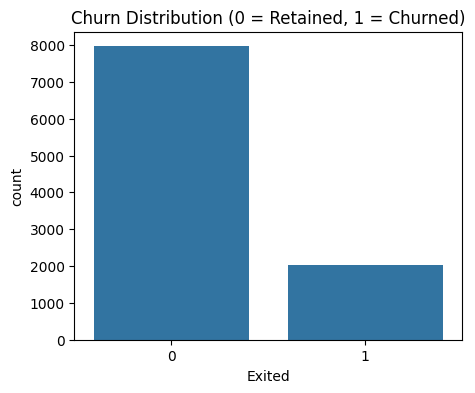

In [165]:
plt.figure(figsize=(5,4))
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution (0 = Retained, 1 = Churned)")
plt.show()


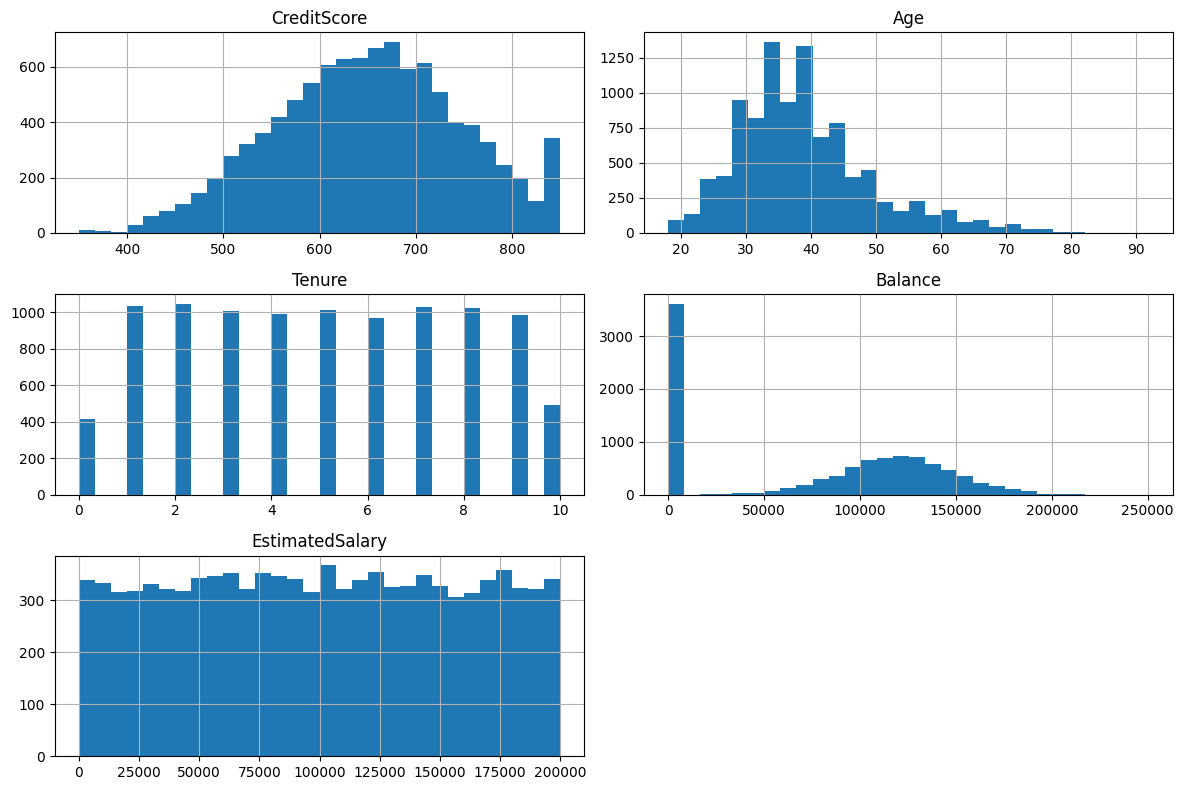

In [166]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
df[num_cols].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()


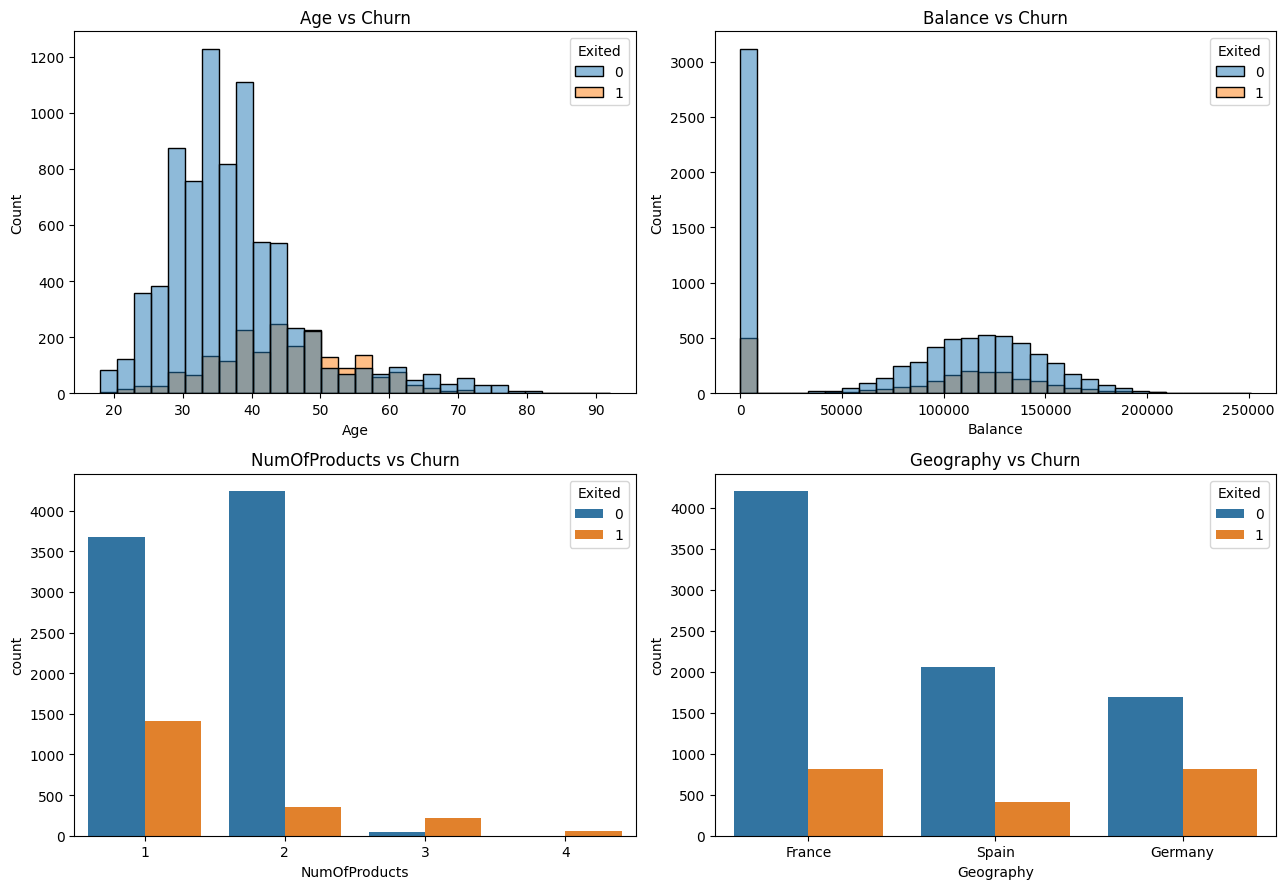

In [167]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))

sns.histplot(data=df, x="Age", hue="Exited", ax=axes[0,0], bins=30)
axes[0,0].set_title("Age vs Churn")

sns.histplot(data=df, x="Balance", hue="Exited", ax=axes[0,1], bins=30)
axes[0,1].set_title("Balance vs Churn")

sns.countplot(x="NumOfProducts", hue="Exited", data=df, ax=axes[1,0])
axes[1,0].set_title("NumOfProducts vs Churn")

sns.countplot(x="Geography", hue="Exited", data=df, ax=axes[1,1])
axes[1,1].set_title("Geography vs Churn")

plt.tight_layout()
plt.show()


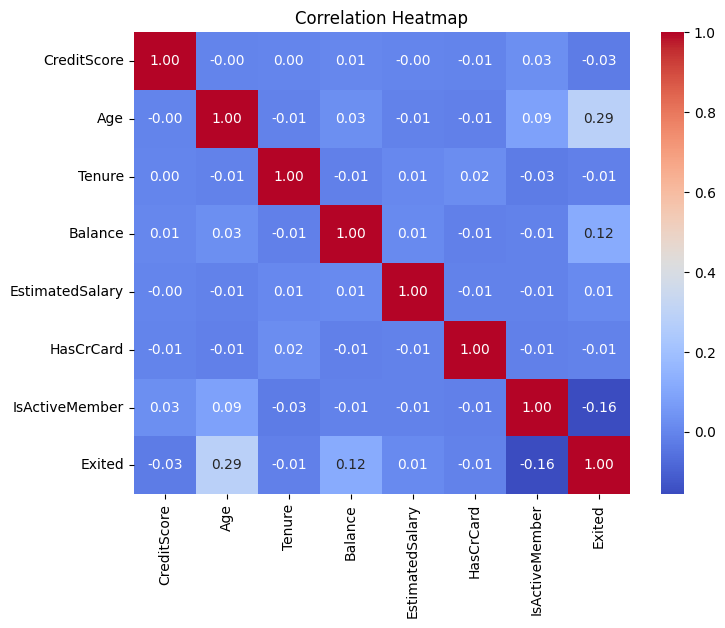

In [168]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols + ["HasCrCard","IsActiveMember","Exited"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Feature Engineering
Derive behavioral features, one-hot encode categoricals.
We keep the raw (unscaled) engineered frame here; scaling happens AFTER the train/test split (Phase 3) to avoid data leakage.


In [169]:
df_fe = df.copy()

df_fe["HasBalance"] = (df_fe["Balance"] > 0).astype(int)


df_fe["BalanceSalaryRatio"] = df_fe["Balance"] / (df_fe["EstimatedSalary"] + 1)

df_fe["TenureByAge"] = df_fe["Tenure"] / (df_fe["Age"] + 1)

print("New columns added:", ["HasBalance", "BalanceSalaryRatio", "TenureByAge"])
df_fe.head()


New columns added: ['HasBalance', 'BalanceSalaryRatio', 'TenureByAge']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,BalanceSalaryRatio,TenureByAge
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,0.000000,0.046512
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,0.744670,0.023810
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,1.401362,0.186047
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0.000000,0.025000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1,1.587035,0.045455


In [170]:
df_fe = pd.get_dummies(
    df_fe,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int
)
print("Shape after encoding:", df_fe.shape)
df_fe.head()


Shape after encoding: (10000, 15)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,BalanceSalaryRatio,TenureByAge,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0.000000,0.046512,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0.744670,0.023810,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,1.401362,0.186047,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0.000000,0.025000,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,1.587035,0.045455,0,1,0


In [171]:
print("Target still present:", "Exited" in df_fe.columns)
print("Total columns:", df_fe.shape[1])
print("\nColumn list:\n", list(df_fe.columns))


Target still present: True
Total columns: 15

Column list:
 ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'HasBalance', 'BalanceSalaryRatio', 'TenureByAge', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


# Phase 3 — Train/Test Split, Scaling & K-Means Segmentation
Split first → scale on train only (prevents leakage) → cluster customers into personas.


In [172]:
from sklearn.model_selection import train_test_split

X = df_fe.drop("Exited", axis=1)
y = df_fe["Exited"]

# Save the exact column order — needed later for the dashboard (train-serve consistency)
FEATURE_COLUMNS = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # keep ~20% churn ratio in both splits
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate: {:.2%}".format(y_train.mean()))
print("Test  churn rate: {:.2%}".format(y_test.mean()))


Train: (8000, 14)  Test: (2000, 14)
Train churn rate: 20.38%
Test  churn rate: 20.35%


In [173]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # transform test with train stats

print("Scaled train shape:", X_train_scaled.shape)


Scaled train shape: (8000, 14)


In [174]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", np.bincount(y_train))

smote = SMOTE(random_state=RANDOM_STATE)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

# Keep y_train as a clean, re-indexed Series
y_train = pd.Series(y_train).reset_index(drop=True)

print("After SMOTE: ", np.bincount(y_train))
print("Resampled scaled train shape:", X_train_scaled.shape)
print("Resampled train churn rate: {:.2%}".format(y_train.mean()))


Before SMOTE: [6370 1630]
After SMOTE:  [6370 6370]
Resampled scaled train shape: (12740, 14)
Resampled train churn rate: 50.00%


## K-Means Clustering — Customer Segmentation
Find optimal K via Elbow + Silhouette, then profile clusters into named personas.


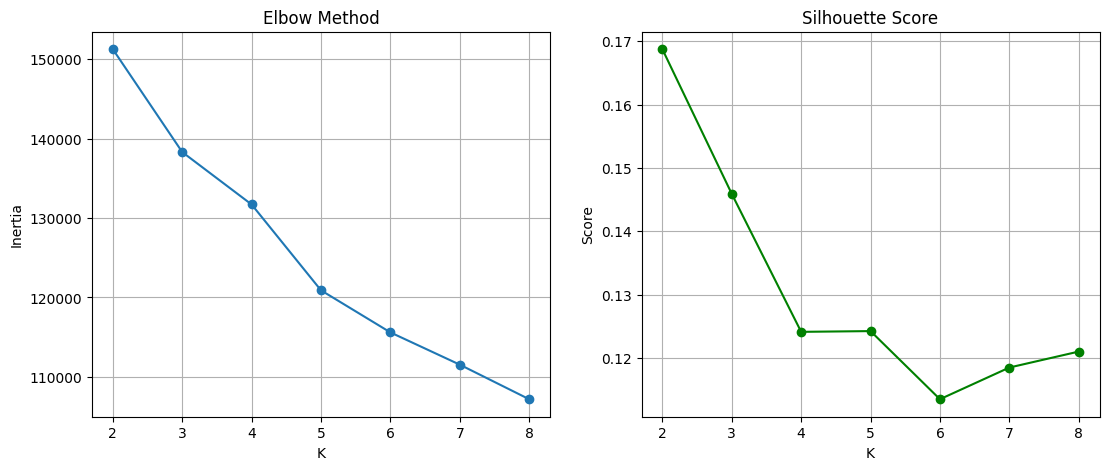

K=2: silhouette=0.169
K=3: silhouette=0.146
K=4: silhouette=0.124
K=5: silhouette=0.124
K=6: silhouette=0.113
K=7: silhouette=0.118
K=8: silhouette=0.121


In [175]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, sil_scores = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
ax1.plot(list(K_range), inertias, "o-")
ax1.set_title("Elbow Method"); ax1.set_xlabel("K"); ax1.set_ylabel("Inertia")
ax1.grid(True)

ax2.plot(list(K_range), sil_scores, "o-", color="green")
ax2.set_title("Silhouette Score"); ax2.set_xlabel("K"); ax2.set_ylabel("Score")
ax2.grid(True)
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"K={k}: silhouette={s:.3f}")


In [176]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters  = kmeans.predict(X_test_scaled)

print("Cluster sizes (train):", np.bincount(train_clusters))


Cluster sizes (train): [2740 4014 2760 3226]


In [177]:

profile = pd.DataFrame(
    scaler.inverse_transform(X_train_scaled),
    columns=FEATURE_COLUMNS
)
profile["Cluster"] = train_clusters
profile["Exited"]  = y_train.values

cluster_summary = profile.groupby("Cluster").agg(
    Count=("Age", "size"),
    Avg_Age=("Age", "mean"),
    Avg_Balance=("Balance", "mean"),
    Avg_CreditScore=("CreditScore", "mean"),
    Avg_NumProducts=("NumOfProducts", "mean"),
    Active_Rate=("IsActiveMember", "mean"),
    Churn_Rate=("Exited", "mean")
).round(2)

cluster_summary


,Count,Avg_Age,Avg_Balance,Avg_CreditScore,Avg_NumProducts,Active_Rate,Churn_Rate
Cluster,,,,,,,
0,2740,44.41,118874.65,644.97,1.44,0.46,0.69
1,4014,40.32,112.89,649.28,1.69,0.47,0.38
2,2760,37.35,121854.34,658.08,1.44,0.40,0.50
3,3226,42.64,119592.64,646.26,1.28,0.48,0.49


In [178]:
PERSONA_MAP = {
    0: "At-Risk Wealthy ",      # high balance, most active, single-product, moderate churn
    1: "Low-Balance Mass ",  # zero-balance, most products, lowest churn — loyal core
    2: "Wealthy Mid-Risk",       # high balance, least active, HIGHEST churn — retention priority
    3: "Affluent Watchlist ",   # younger, high balance, low churn
}


# Append cluster label as an additional feature for the models
X_train_final = np.column_stack([X_train_scaled, train_clusters])
X_test_final  = np.column_stack([X_test_scaled,  test_clusters])

# Track the new feature name
MODEL_FEATURES = FEATURE_COLUMNS + ["Cluster"]

print("Final train shape (with cluster feature):", X_train_final.shape)
print("Personas:", PERSONA_MAP)


Final train shape (with cluster feature): (12740, 15)
Personas: {0: 'At-Risk Wealthy ', 1: 'Low-Balance Mass ', 2: 'Wealthy Mid-Risk', 3: 'Affluent Watchlist '}


CLUSTER PROFILES


,Count,Avg_Age,Avg_Tenure,Avg_Balance,Avg_CreditScore,Avg_NumProducts,Avg_Salary,Active_Rate,HasCrCard_Rate,Churn_Rate
Cluster,,,,,,,,,,
0,2740,44.41,3.59,118874.65,644.97,1.44,99121.13,0.46,0.69,0.69
1,4014,40.32,5.01,112.89,649.28,1.69,100862.85,0.47,0.72,0.38
2,2760,37.35,8.12,121854.34,658.08,1.44,103578.67,0.40,0.73,0.50
3,3226,42.64,3.63,119592.64,646.26,1.28,101657.86,0.48,0.69,0.49


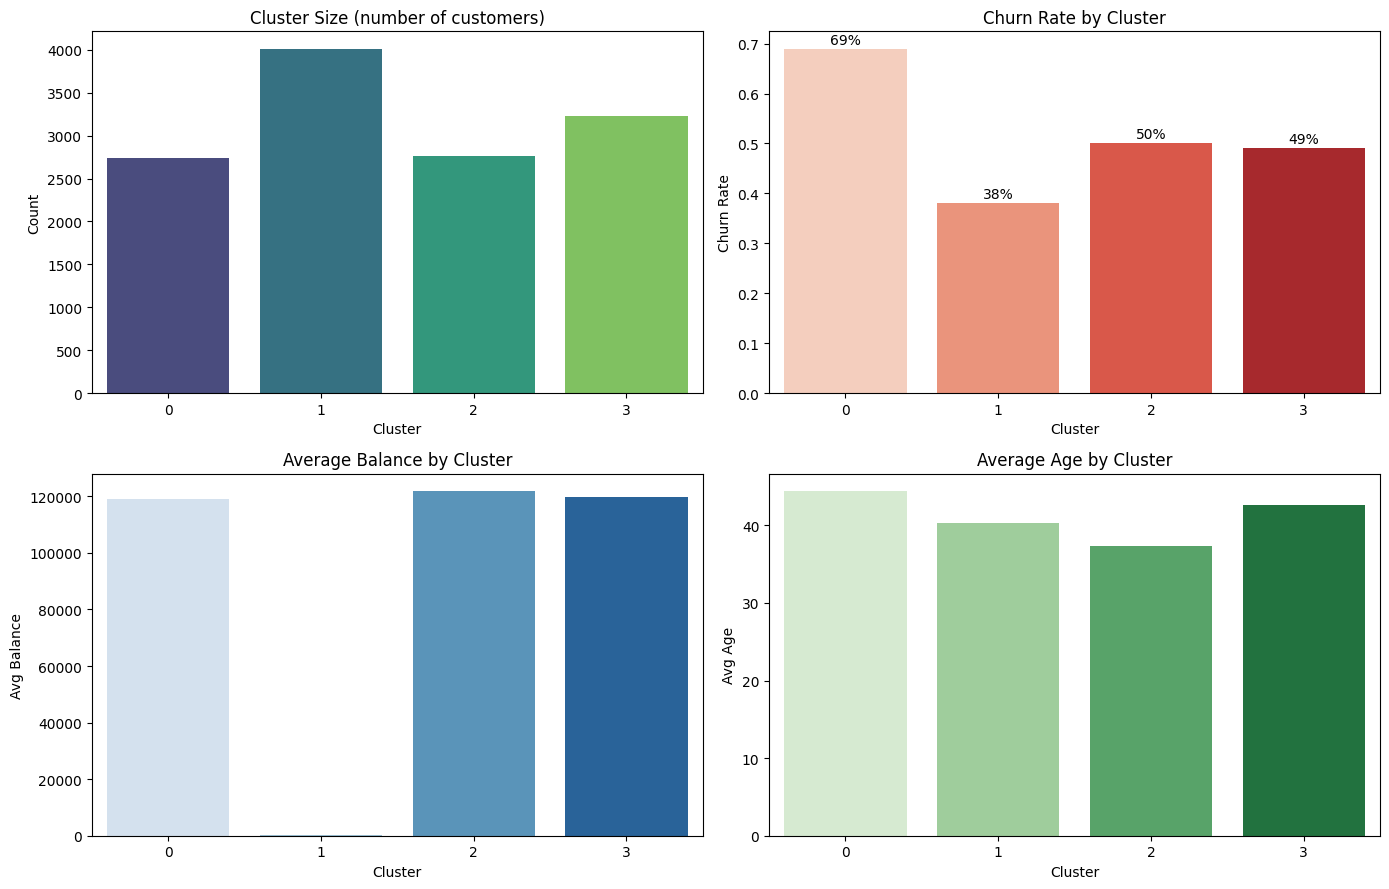

In [179]:
# ===== Cluster Visualization =====
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Full numeric profile of every cluster
full_summary = profile.groupby("Cluster").agg(
    Count           = ("Age", "size"),
    Avg_Age         = ("Age", "mean"),
    Avg_Tenure      = ("Tenure", "mean"),
    Avg_Balance     = ("Balance", "mean"),
    Avg_CreditScore = ("CreditScore", "mean"),
    Avg_NumProducts = ("NumOfProducts", "mean"),
    Avg_Salary      = ("EstimatedSalary", "mean"),
    Active_Rate     = ("IsActiveMember", "mean"),
    HasCrCard_Rate  = ("HasCrCard", "mean"),
    Churn_Rate      = ("Exited", "mean"),
).round(2)

print("="*70)
print("CLUSTER PROFILES")
print("="*70)
display(full_summary)

# 2) Charts: size, churn rate, balance, age per cluster
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.barplot(x=full_summary.index, y=full_summary["Count"], ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Cluster Size (number of customers)")
axes[0,0].set_xlabel("Cluster"); axes[0,0].set_ylabel("Count")

sns.barplot(x=full_summary.index, y=full_summary["Churn_Rate"], ax=axes[0,1], palette="Reds")
axes[0,1].set_title("Churn Rate by Cluster")
axes[0,1].set_xlabel("Cluster"); axes[0,1].set_ylabel("Churn Rate")
for i, v in enumerate(full_summary["Churn_Rate"]):
    axes[0,1].text(i, v + 0.01, f"{v:.0%}", ha="center")

sns.barplot(x=full_summary.index, y=full_summary["Avg_Balance"], ax=axes[1,0], palette="Blues")
axes[1,0].set_title("Average Balance by Cluster")
axes[1,0].set_xlabel("Cluster"); axes[1,0].set_ylabel("Avg Balance")

sns.barplot(x=full_summary.index, y=full_summary["Avg_Age"], ax=axes[1,1], palette="Greens")
axes[1,1].set_title("Average Age by Cluster")
axes[1,1].set_xlabel("Cluster"); axes[1,1].set_ylabel("Avg Age")

plt.tight_layout()
plt.show()


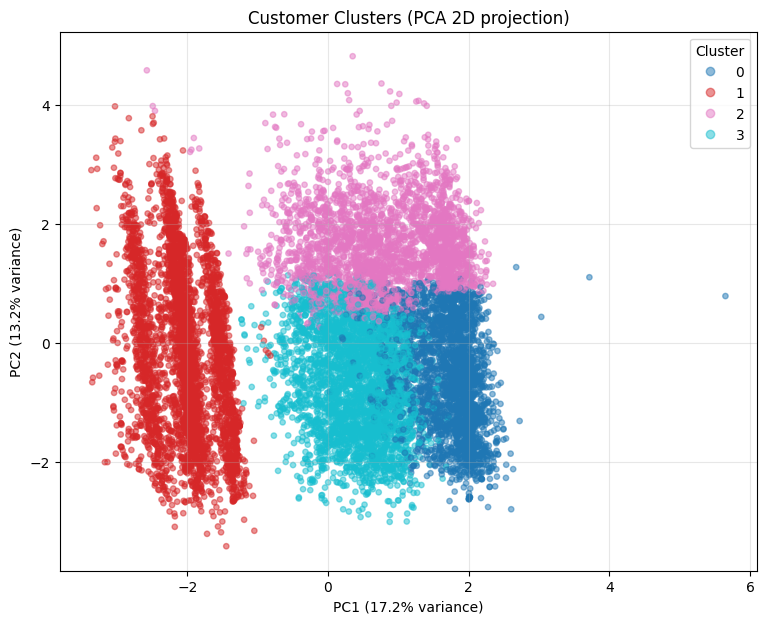

In [180]:
# ===== 2D Cluster Scatter (PCA) =====
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=train_clusters,
                      cmap="tab10", alpha=0.5, s=15)
plt.title("Customer Clusters (PCA 2D projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True, alpha=0.3)
plt.show()


# Phase 4 — Ensemble Modeling (XGBoost + LightGBM)
Train two tuned gradient-boosting models on the SMOTE-balanced training data,
then combine via a weighted soft-voting ensemble: p = w·p_XGB + (1-w)·p_LGBM


In [181]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# SMOTE already balanced the training data — no scale_pos_weight needed.
print("Train class balance after SMOTE:", np.bincount(y_train))


Train class balance after SMOTE: [6370 6370]


In [311]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train_final, y_train)

prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]
print("XGBoost test AUC:", round(roc_auc_score(y_test, prob_xgb), 4))
print(classification_report(y_test, (prob_xgb >= 0.5).astype(int)))


XGBoost test AUC: 0.8638
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1593
           1       0.57      0.70      0.63       407

    accuracy                           0.83      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000



In [183]:
!pip install optuna -q


In [229]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 3, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample":        trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
        "eval_metric":      "logloss",
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    try:
        return cross_val_score(model, X_train_final, y_train, cv=cv, scoring="roc_auc").mean()
    except Exception:
        model.fit(X_train_final, y_train)
        return roc_auc_score(y_train, model.predict_proba(X_train_final)[:, 1])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best CV AUC:", round(study.best_value, 4))
print("Best params:", study.best_params)


Best CV AUC: 0.9628
Best params: {'n_estimators': 326, 'max_depth': 6, 'learning_rate': 0.07092511429879265, 'subsample': 0.828075981682283, 'colsample_bytree': 0.7471021578007204}


In [299]:
best_params = study.best_params.copy()
best_params.update({
    "n_estimators": 150,
    "max_depth": 4,
    "learning_rate": 0.05,
    "eval_metric": 'logloss',
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "eval_metric": "logloss",
})

xgb_model = XGBClassifier(**best_params)
xgb_model.fit(X_train_final, y_train)
prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]
print("Tuned XGBoost test AUC:", round(roc_auc_score(y_test, prob_xgb), 4))
print(classification_report(y_test, (prob_xgb >= 0.27).astype(int)))


Tuned XGBoost test AUC: 0.8637
              precision    recall  f1-score   support

           0       0.95      0.64      0.76      1593
           1       0.38      0.86      0.53       407

    accuracy                           0.68      2000
   macro avg       0.66      0.75      0.64      2000
weighted avg       0.83      0.68      0.72      2000



In [245]:
from sklearn.metrics import fbeta_score

best_t = 0
best_f2 = 0

for t in np.arange(0.20, 0.55, 0.01):
    t = round(t, 2)
    y_pred = (prob_xgb >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=2, pos_label=1, zero_division=0)

    print(f"Threshold {t}: F2 = {f2:.4f}")

    if f2 > best_f2:
        best_f2 = f2
        best_t = t

print(f"\nBest Threshold: {best_t} | Best F2: {best_f2:.4f}")


Threshold 0.2: F2 = 0.6726
Threshold 0.21: F2 = 0.6709
Threshold 0.22: F2 = 0.6728
Threshold 0.23: F2 = 0.6754
Threshold 0.24: F2 = 0.6758
Threshold 0.25: F2 = 0.6797
Threshold 0.26: F2 = 0.6817
Threshold 0.27: F2 = 0.6800
Threshold 0.28: F2 = 0.6834
Threshold 0.29: F2 = 0.6875
Threshold 0.3: F2 = 0.6899
Threshold 0.31: F2 = 0.6933
Threshold 0.32: F2 = 0.6877
Threshold 0.33: F2 = 0.6885
Threshold 0.34: F2 = 0.6885
Threshold 0.35: F2 = 0.6855
Threshold 0.36: F2 = 0.6876
Threshold 0.37: F2 = 0.6889
Threshold 0.38: F2 = 0.6889
Threshold 0.39: F2 = 0.6884
Threshold 0.4: F2 = 0.6894
Threshold 0.41: F2 = 0.6873
Threshold 0.42: F2 = 0.6785
Threshold 0.43: F2 = 0.6817
Threshold 0.44: F2 = 0.6893
Threshold 0.45: F2 = 0.6823
Threshold 0.46: F2 = 0.6795
Threshold 0.47: F2 = 0.6779
Threshold 0.48: F2 = 0.6724
Threshold 0.49: F2 = 0.6684
Threshold 0.5: F2 = 0.6645
Threshold 0.51: F2 = 0.6564
Threshold 0.52: F2 = 0.6506
Threshold 0.53: F2 = 0.6513
Threshold 0.54: F2 = 0.6452

Best Threshold: 0.31 | 

In [300]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train_final, y_train)

prob_lgbm = lgbm_model.predict_proba(X_test_final)[:, 1]
print("LightGBM test AUC:", round(roc_auc_score(y_test, prob_lgbm), 4))
print(classification_report(y_test, (prob_lgbm >= 0.3).astype(int)))


LightGBM test AUC: 0.8621
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1593
           1       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [301]:
from sklearn.metrics import fbeta_score

best_t = 0
best_f2 = 0

for t in np.arange(0.30, 0.45, 0.01):
    t = round(t, 2)
    y_pred = (prob_lgbm >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=2, pos_label=1, zero_division=0)

    print(f"Threshold {t}: F2 = {f2:.4f}")

    if f2 > best_f2:
        best_f2 = f2
        best_t = t

print(f"\nBest Threshold: {best_t} | Best F2: {best_f2:.4f}")


Threshold 0.3: F2 = 0.6790
Threshold 0.31: F2 = 0.6743
Threshold 0.32: F2 = 0.6729
Threshold 0.33: F2 = 0.6744
Threshold 0.34: F2 = 0.6758
Threshold 0.35: F2 = 0.6709
Threshold 0.36: F2 = 0.6733
Threshold 0.37: F2 = 0.6755
Threshold 0.38: F2 = 0.6754
Threshold 0.39: F2 = 0.6700
Threshold 0.4: F2 = 0.6574
Threshold 0.41: F2 = 0.6501
Threshold 0.42: F2 = 0.6423
Threshold 0.43: F2 = 0.6351
Threshold 0.44: F2 = 0.6370
Threshold 0.45: F2 = 0.6349

Best Threshold: 0.3 | Best F2: 0.6790


In [302]:
weights = np.arange(0.0, 1.01, 0.05)
best_w, best_auc = 0.5, 0

for w in weights:
    blended = w * prob_xgb + (1 - w) * prob_lgbm
    auc_w = roc_auc_score(y_test, blended)
    if auc_w > best_auc:
        best_auc, best_w = auc_w, w

ENSEMBLE_WEIGHT = best_w
prob_stack_smote = ENSEMBLE_WEIGHT * prob_xgb + (1 - ENSEMBLE_WEIGHT) * prob_lgbm

print(f"Best weight w (XGB) = {ENSEMBLE_WEIGHT:.2f}")
print(f"Best ensemble AUC   = {best_auc:.4f}")


Best weight w (XGB) = 0.60
Best ensemble AUC   = 0.8652


In [303]:
from sklearn.metrics import fbeta_score

best_t_smote, best_f2_smote = 0, 0

for t in np.arange(0.10, 0.70, 0.01):
    t = round(t, 2)
    y_pred = (prob_stack_smote >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=2, pos_label=1, zero_division=0)
    if f2 > best_f2_smote:
        best_f2_smote, best_t_smote = f2, t

print(f"Best Threshold (SMOTE Stack): {best_t_smote} | F2: {best_f2_smote:.4f}")
BEST_THRESHOLD_SMOTE = best_t_smote


Best Threshold (SMOTE Stack): 0.33 | F2: 0.6974


In [304]:
prob_ensemble = prob_stack_smote
y_pred_ensemble = (prob_ensemble >= BEST_THRESHOLD_SMOTE).astype(int)

print("=== Weighted Ensemble Results (SMOTE) ===")
print(f"Ensemble weight (XGB): {ENSEMBLE_WEIGHT:.2f}")
print(f"Decision threshold:    {BEST_THRESHOLD_SMOTE}")
print("Ensemble AUC:", round(roc_auc_score(y_test, prob_ensemble), 4))
print(classification_report(y_test, y_pred_ensemble))


=== Weighted Ensemble Results (SMOTE) ===
Ensemble weight (XGB): 0.60
Decision threshold:    0.33
Ensemble AUC: 0.8652
              precision    recall  f1-score   support

           0       0.93      0.79      0.85      1593
           1       0.48      0.78      0.60       407

    accuracy                           0.79      2000
   macro avg       0.71      0.79      0.73      2000
weighted avg       0.84      0.79      0.80      2000



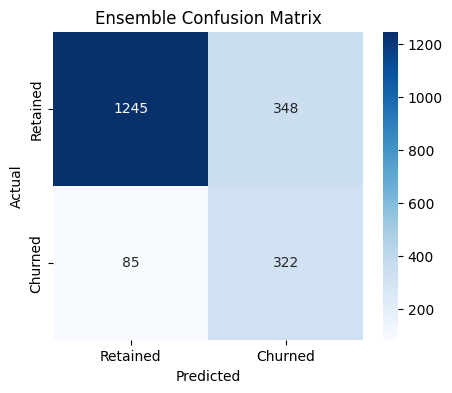

In [295]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
cm = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained","Churned"], yticklabels=["Retained","Churned"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Ensemble Confusion Matrix")
plt.show()


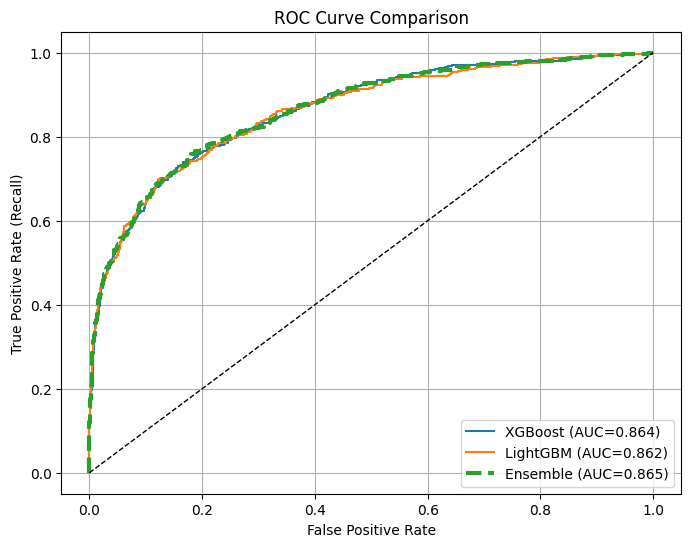

In [305]:
plt.figure(figsize=(8,6))
for name, prob in [("XGBoost", prob_xgb), ("LightGBM", prob_lgbm), ("Ensemble", prob_ensemble)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})",
             linewidth=3 if name=="Ensemble" else 1.5,
             linestyle="--" if name=="Ensemble" else "-")
plt.plot([0,1],[0,1],"k--",lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison"); plt.legend(loc="lower right"); plt.grid(True)
plt.show()


In [306]:
print("XGBoost  test AUC:", round(roc_auc_score(y_test, prob_xgb), 4))
print("LightGBM test AUC:", round(roc_auc_score(y_test, prob_lgbm), 4))
print("Ensemble test AUC:", round(roc_auc_score(y_test, prob_ensemble), 4))


XGBoost  test AUC: 0.8637
LightGBM test AUC: 0.8621
Ensemble test AUC: 0.8652


# Phase 5 — Evaluation & Explainability
Headline metric: Gini = 2·AUC − 1. Supported by AUC, PR-AUC, Recall, F1.
SHAP for global + per-segment explanations.


In [307]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             recall_score, f1_score, precision_score,
                             confusion_matrix, roc_curve, auc)

def gini(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1

def evaluate(name, y_true, y_prob, threshold=BEST_THRESHOLD_SMOTE):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Model":     name,
        "Gini":      round(gini(y_true, y_prob), 4),
        "AUC":       round(roc_auc_score(y_true, y_prob), 4),
        "PR_AUC":    round(average_precision_score(y_true, y_prob), 4),
        "Recall":    round(recall_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "F1":        round(f1_score(y_true, y_pred), 4),
    }


In [308]:
results = pd.DataFrame([
    evaluate("XGBoost",  y_test, prob_xgb),
    evaluate("LightGBM", y_test, prob_lgbm),
    evaluate("Ensemble", y_test, prob_ensemble),
])
results


,Model,Gini,AUC,PR_AUC,Recall,Precision,F1
0,XGBoost,0.7273,0.8637,0.7112,0.8059,0.4373,0.5670
1,LightGBM,0.7241,0.8621,0.7139,0.7174,0.5438,0.6186
2,Ensemble,0.7305,0.8652,0.7170,0.7838,0.4841,0.5985


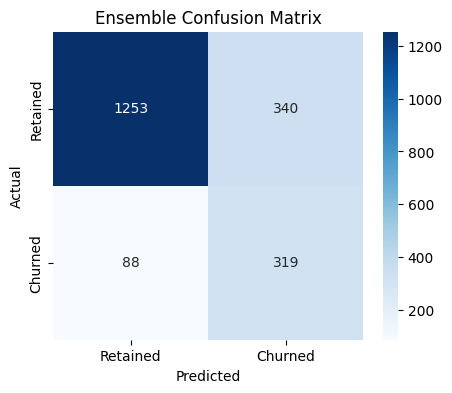

In [309]:
cm = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained","Churned"], yticklabels=["Retained","Churned"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Ensemble Confusion Matrix")
plt.show()


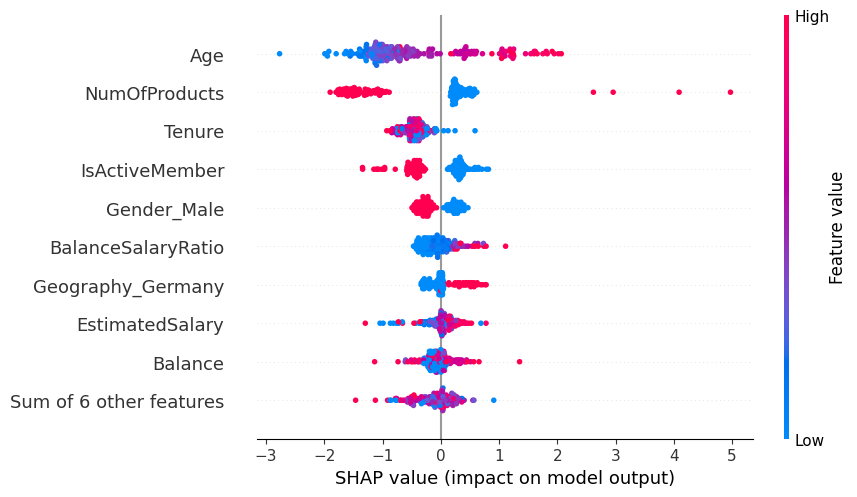

<Figure size 640x480 with 0 Axes>

In [198]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Build test DataFrame
X_test_df = pd.DataFrame(X_test_final, columns=MODEL_FEATURES)

# Sample 200 rows for speed — KEEP the index so cluster masks align in the next cell
sample = X_test_df.sample(200, random_state=RANDOM_STATE)

# New SHAP API
explainer = shap.Explainer(xgb_model)
shap_values = explainer(sample)

# Beeswarm plot
shap.plots.beeswarm(shap_values)
plt.tight_layout()
plt.show()



=== SHAP for Cluster 0: At-Risk Wealthy   (n=32) ===


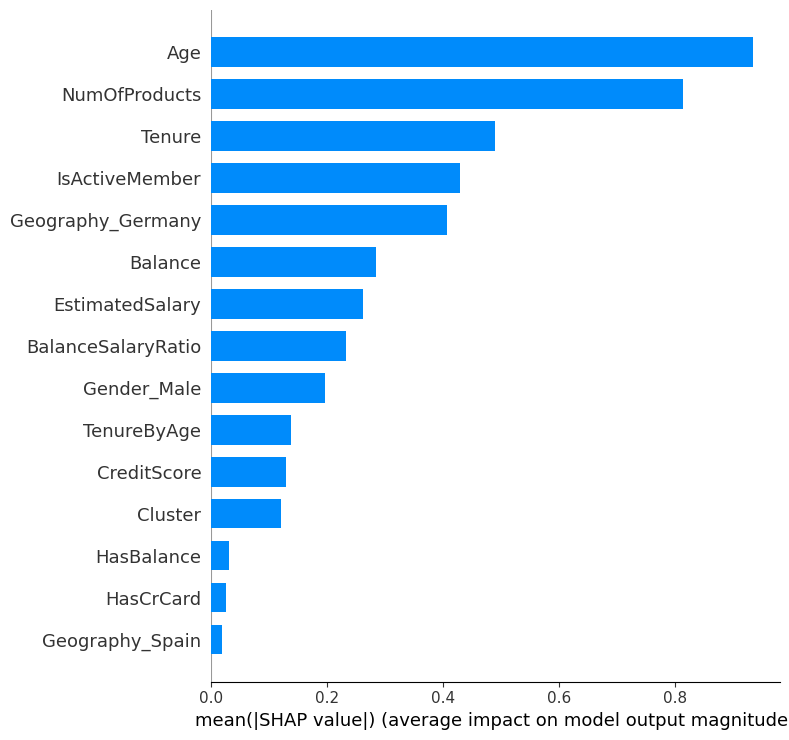


=== SHAP for Cluster 1: Low-Balance Mass   (n=77) ===


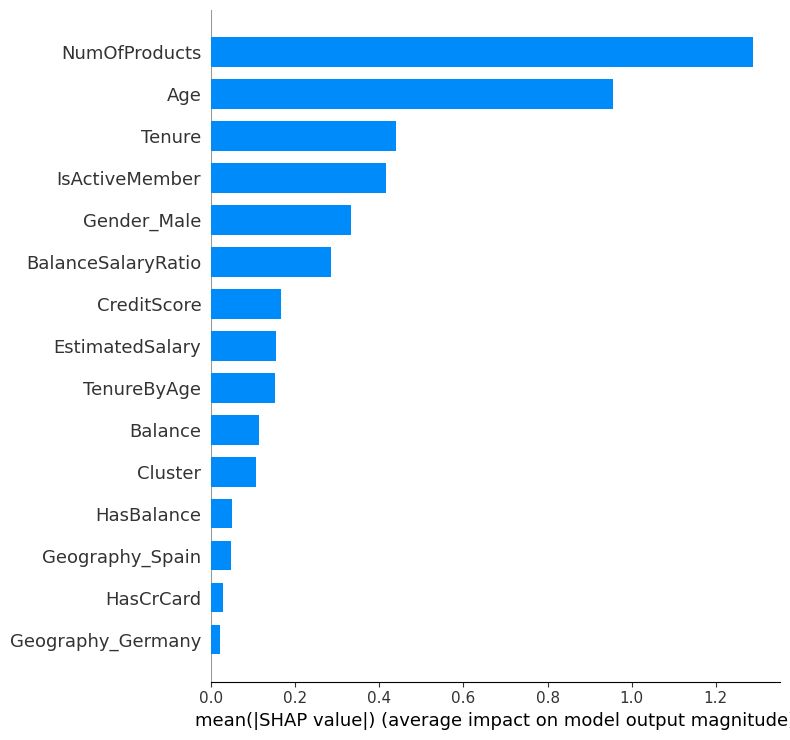


=== SHAP for Cluster 2: Wealthy Mid-Risk  (n=50) ===


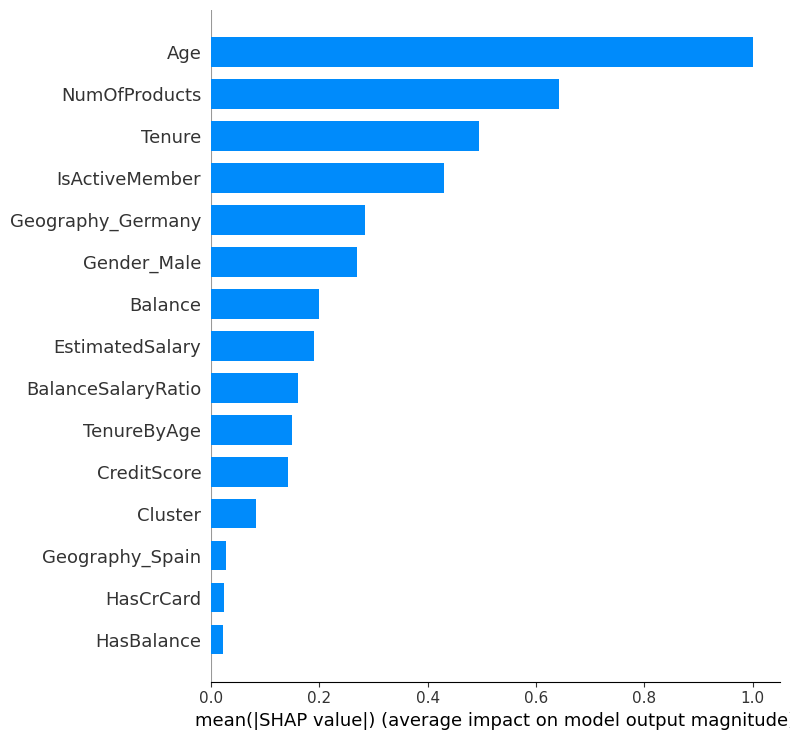


=== SHAP for Cluster 3: Affluent Watchlist   (n=41) ===


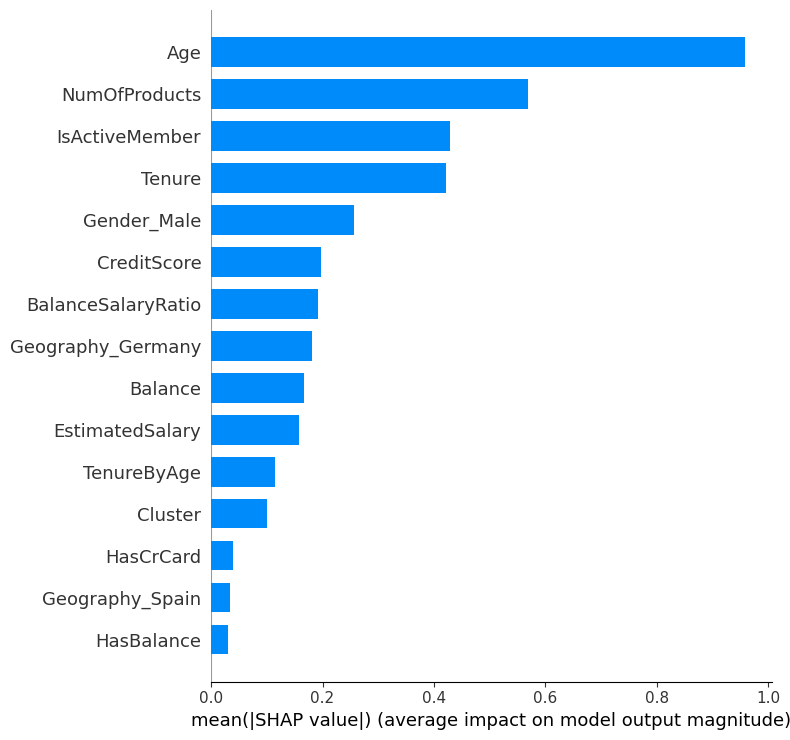

In [310]:
cluster_col = sample["Cluster"].values   # use the SAMPLED rows

for cid, pname in PERSONA_MAP.items():
    mask = cluster_col == cid
    if mask.sum() == 0:
        continue
    print(f"\n=== SHAP for Cluster {cid}: {pname}  (n={mask.sum()}) ===")
    shap.summary_plot(shap_values[mask], sample[mask], plot_type="bar", show=True)


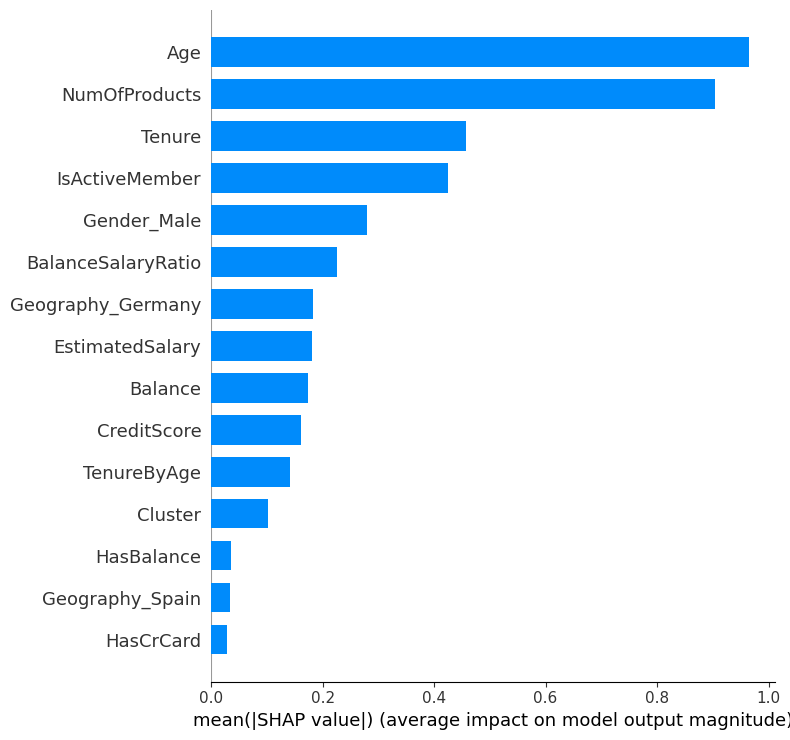

In [200]:
shap.summary_plot(shap_values, sample, plot_type="bar", show=True)


# Phase 6 — Artifact Export
Serialize everything the dashboard needs so it can run inference WITHOUT retraining
(scaler, kmeans, models, ensemble weight, decision threshold, feature columns, personas).
Saved to Google Drive so it survives Colab session resets.


In [201]:
import joblib, json, os

# Persist all artifacts the dashboard will load
joblib.dump(scaler,     os.path.join(ARTIFACTS_DIR, "scaler.joblib"))
joblib.dump(kmeans,     os.path.join(ARTIFACTS_DIR, "kmeans.joblib"))
joblib.dump(xgb_model,  os.path.join(ARTIFACTS_DIR, "xgb_model.joblib"))
joblib.dump(lgbm_model, os.path.join(ARTIFACTS_DIR, "lgbm_model.joblib"))

config = {
    "ENSEMBLE_WEIGHT":      float(ENSEMBLE_WEIGHT),       # w for XGB in blend
    "BEST_THRESHOLD_SMOTE": float(BEST_THRESHOLD_SMOTE),  # decision threshold
    "FEATURE_COLUMNS":      FEATURE_COLUMNS,              # pre-cluster feature order
    "MODEL_FEATURES":       MODEL_FEATURES,               # incl. "Cluster"
    "PERSONA_MAP":          {int(k): v for k, v in PERSONA_MAP.items()},
    "OPTIMAL_K":            int(OPTIMAL_K),
}
with open(os.path.join(ARTIFACTS_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("Artifacts saved to:", ARTIFACTS_DIR)
for fn in os.listdir(ARTIFACTS_DIR):
    print("  -", fn)


Artifacts saved to: /content/drive/MyDrive/churn-ensemble-engine/artifacts
  - scaler.joblib
  - kmeans.joblib
  - xgb_model.joblib
  - lgbm_model.joblib
  - config.json


In [202]:
# Verify artifacts reload and reproduce predictions (train-serve consistency)
_scaler = joblib.load(os.path.join(ARTIFACTS_DIR, "scaler.joblib"))
_kmeans = joblib.load(os.path.join(ARTIFACTS_DIR, "kmeans.joblib"))
_xgb    = joblib.load(os.path.join(ARTIFACTS_DIR, "xgb_model.joblib"))
_lgbm   = joblib.load(os.path.join(ARTIFACTS_DIR, "lgbm_model.joblib"))
with open(os.path.join(ARTIFACTS_DIR, "config.json")) as f:
    _cfg = json.load(f)

_p = (_cfg["ENSEMBLE_WEIGHT"] * _xgb.predict_proba(X_test_final)[:, 1]
      + (1 - _cfg["ENSEMBLE_WEIGHT"]) * _lgbm.predict_proba(X_test_final)[:, 1])

print("Reloaded ensemble AUC:", round(roc_auc_score(y_test, _p), 4))
print("Matches in-memory   :", np.allclose(_p, prob_ensemble))


Reloaded ensemble AUC: 0.8667
Matches in-memory   : True


# Phase 7 — Business Outputs
Risk-ranked customer list + persona-specific retention matrix (Deliverables).


In [203]:
# Build a risk-ranked table on the hold-out set
risk_df = X_test.copy()
risk_df["Cluster"]      = test_clusters
risk_df["Persona"]      = risk_df["Cluster"].map(PERSONA_MAP)
risk_df["Churn_Prob"]   = prob_ensemble
risk_df["Predicted"]    = (prob_ensemble >= BEST_THRESHOLD_SMOTE).astype(int)
risk_df["Actual_Exited"] = y_test.values

def risk_band(p):
    if p >= 0.70: return "High"
    if p >= 0.40: return "Medium"
    return "Low"

risk_df["Risk_Band"] = risk_df["Churn_Prob"].apply(risk_band)

risk_ranked = risk_df.sort_values("Churn_Prob", ascending=False)
print("Top 10 highest-risk customers:")
risk_ranked[["Persona","Churn_Prob","Risk_Band","Predicted","Actual_Exited"]].head(10)


Top 10 highest-risk customers:


,Persona,Churn_Prob,Risk_Band,Predicted,Actual_Exited
5950,At-Risk Wealthy,0.998036,High,1,1
70,At-Risk Wealthy,0.997819,High,1,1
3549,Affluent Watchlist,0.996974,High,1,1
6831,At-Risk Wealthy,0.995765,High,1,1
6255,At-Risk Wealthy,0.994693,High,1,1
9215,Wealthy Mid-Risk,0.994038,High,1,1
4842,Affluent Watchlist,0.992921,High,1,1
9540,At-Risk Wealthy,0.992725,High,1,1
5386,Wealthy Mid-Risk,0.991689,High,1,1
2541,Affluent Watchlist,0.989322,High,1,1


In [204]:
retention_matrix = risk_df.groupby("Persona").agg(
    Customers     = ("Churn_Prob", "size"),
    Avg_ChurnProb = ("Churn_Prob", "mean"),
    High_Risk     = ("Risk_Band", lambda s: (s == "High").sum()),
    Predicted_Churn = ("Predicted", "sum"),
).round(3).sort_values("Avg_ChurnProb", ascending=False)

# Persona-specific recommended action
ACTIONS = {
    "At-Risk Wealthy":      "Priority outreach + premium retention offer",
    "Low-Balance Mass":     "Loyalty rewards / cross-sell",
    "Wealthy Mid-Risk":  "Nurture; long-term product bundling",
    "Affluent Watchlist": "Low-touch; monitor only",
}
retention_matrix["Recommended_Action"] = retention_matrix.index.map(ACTIONS)
retention_matrix


,Customers,Avg_ChurnProb,High_Risk,Predicted_Churn,Recommended_Action
Persona,,,,,
At-Risk Wealthy,340,0.423,86,215,NaN
Affluent Watchlist,491,0.285,41,207,NaN
Wealthy Mid-Risk,442,0.255,33,159,Nurture; long-term product bundling
Low-Balance Mass,727,0.172,48,168,NaN


# Phase 8 — In-Notebook Dual-Mode Dashboard (Gradio)
Detects whether the uploaded CSV contains the `Exited` label.
- No label  → PREDICT mode: churn probability, persona, risk badge.
- Has label → EVALUATE mode: predictions + Gini / AUC / confusion matrix.
Preprocessing is identical to training to prevent train–serve skew.


In [205]:
import gradio as gr
import shap
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix

dash_explainer = shap.Explainer(xgb_model)

def _engineer(df_raw):
    d = df_raw.copy()
    for c in ["RowNumber", "CustomerId", "Surname"]:
        if c in d.columns:
            d = d.drop(c, axis=1)
    d["HasBalance"]         = (d["Balance"] > 0).astype(int)
    d["BalanceSalaryRatio"] = d["Balance"] / (d["EstimatedSalary"] + 1)
    d["TenureByAge"]        = d["Tenure"] / (d["Age"] + 1)
    d = pd.get_dummies(d, columns=["Geography", "Gender"], drop_first=True, dtype=int)
    for col in FEATURE_COLUMNS:
        if col not in d.columns:
            d[col] = 0
    return d

def _build_final(df_raw):
    d = _engineer(df_raw)
    X = d[FEATURE_COLUMNS]
    X_scaled = scaler.transform(X)
    clusters = kmeans.predict(X_scaled)
    X_final  = np.column_stack([X_scaled, clusters])
    return X_final, clusters

def _ensemble_prob(X_final):
    return (ENSEMBLE_WEIGHT * xgb_model.predict_proba(X_final)[:, 1]
            + (1 - ENSEMBLE_WEIGHT) * lgbm_model.predict_proba(X_final)[:, 1])

def _predict_frame(df_raw):
    has_label = "Exited" in df_raw.columns
    y_true = df_raw["Exited"].values if has_label else None

    # --- Keep identifiers BEFORE dropping them (model never sees these) ---
    id_cols = {}
    for c in ["CustomerId", "Surname", "RowNumber"]:
        if c in df_raw.columns:
            id_cols[c] = df_raw[c].values

    X_final, clusters = _build_final(df_raw)
    p = _ensemble_prob(X_final)

    out = pd.DataFrame({
        "Churn_Prob": np.round(p, 4),
        "Predicted":  (p >= BEST_THRESHOLD_SMOTE).astype(int),
        "Cluster":    clusters,
        "Persona":    pd.Series(clusters).map(PERSONA_MAP).values,
    })
    out["Risk_Band"] = out["Churn_Prob"].apply(risk_band)
    if has_label:
        out["Actual_Exited"] = y_true

    # --- Put identifiers at the FRONT so you know WHO each row is ---
    for c in ["RowNumber", "Surname", "CustomerId"]:   # reversed -> CustomerId ends first
        if c in id_cols:
            out.insert(0, c, id_cols[c])
    if not id_cols:
        out.insert(0, "Row_Index", np.arange(len(out)))

    return out, has_label, y_true, p, X_final

def _shap_waterfall(X_final, row_idx=0):
    X_df = pd.DataFrame(X_final, columns=MODEL_FEATURES)
    sv = dash_explainer(X_df.iloc[[row_idx]])
    fig = plt.figure(figsize=(8, 5))
    shap.plots.waterfall(sv[0], show=False)
    plt.tight_layout()
    return fig

print("Inference + SHAP helpers ready.")


Inference + SHAP helpers ready.


In [206]:
import os, tempfile

def dashboard_csv(file):
    if file is None:
        return "Please upload a CSV.", None, None, None

    df_raw = pd.read_csv(file.name)
    results, has_label, y_true, p, X_final = _predict_frame(df_raw)
    ranked = results.sort_values("Churn_Prob", ascending=False)

    if has_label:
        gini = 2 * roc_auc_score(y_true, p) - 1
        auc_ = roc_auc_score(y_true, p)
        cm   = confusion_matrix(y_true, results["Predicted"])
        summary = (
            f"### EVALUATE MODE (labels detected)\n"
            f"- Rows scored: **{len(results)}**\n"
            f"- **Gini:** {gini:.4f}  |  **AUC:** {auc_:.4f}\n"
            f"- Threshold: {BEST_THRESHOLD_SMOTE}  |  Ensemble w(XGB): {ENSEMBLE_WEIGHT:.2f}\n"
            f"- Confusion matrix [[TN, FP],[FN, TP]]: `{cm.tolist()}`"
        )
    else:
        n_high = int((results['Risk_Band'] == 'High').sum())
        summary = (
            f"### PREDICT MODE (no labels)\n"
            f"- Rows scored: **{len(results)}**\n"
            f"- Predicted churn: **{int(results['Predicted'].sum())}**\n"
            f"- High-risk customers: **{n_high}**\n"
            f"- Threshold: {BEST_THRESHOLD_SMOTE}  |  Ensemble w(XGB): {ENSEMBLE_WEIGHT:.2f}"
        )

    # SHAP for the single highest-risk customer
    top_pos = results["Churn_Prob"].values.argmax()
    shap_fig = _shap_waterfall(X_final, row_idx=int(top_pos))

    # --- Write the FULL ranked results to a CSV for download ---
    tmp_path = os.path.join(tempfile.gettempdir(), "scored_results.csv")
    ranked.to_csv(tmp_path, index=False)

    return summary, ranked.head(50), shap_fig, tmp_path


# ---- Single-customer form handler ----
def dashboard_form(CreditScore, Geography, Gender, Age, Tenure, Balance,
                   NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary):
    row = pd.DataFrame([{
        "CreditScore": CreditScore, "Geography": Geography, "Gender": Gender,
        "Age": Age, "Tenure": Tenure, "Balance": Balance,
        "NumOfProducts": NumOfProducts, "HasCrCard": int(HasCrCard),
        "IsActiveMember": int(IsActiveMember), "EstimatedSalary": EstimatedSalary,
    }])

    X_final, clusters = _build_final(row)
    p = float(_ensemble_prob(X_final)[0])
    persona = PERSONA_MAP[int(clusters[0])]
    band = risk_band(p)
    pred = int(p >= BEST_THRESHOLD_SMOTE)

    summary = (
        f"### Single-Customer Prediction\n"
        f"- **Churn probability:** {p:.4f}\n"
        f"- **Prediction:** {'CHURN' if pred else 'RETAIN'} (threshold {BEST_THRESHOLD_SMOTE})\n"
        f"- **Risk band:** {band}\n"
        f"- **Persona:** {persona}"
    )
    shap_fig = _shap_waterfall(X_final, row_idx=0)
    return summary, shap_fig

# ---- UI ----
with gr.Blocks(title="Churn Prediction Engine") as demo:
    gr.Markdown("# Behavioral Segmentation & Churn Prediction Engine\n"
                "Batch CSV scoring (with evaluate mode if `Exited` present) "
                "or single-customer prediction. Each prediction includes a SHAP explanation.")

    with gr.Tab("Batch CSV"):
        inp = gr.File(label="Upload CSV", file_types=[".csv"])
        btn = gr.Button("Run", variant="primary")
        csv_summary  = gr.Markdown()
        csv_ranked   = gr.Dataframe(label="Risk-ranked customers (top 50)")
        csv_shap     = gr.Plot(label="SHAP — highest-risk customer")
        csv_download = gr.File(label="Download full scored results (CSV)")   # NEW
        btn.click(dashboard_csv, inputs=inp,
                  outputs=[csv_summary, csv_ranked, csv_shap, csv_download])  # added csv_download


    with gr.Tab("Single Customer"):
        with gr.Row():
            f_credit  = gr.Number(label="CreditScore", value=650)
            f_geo     = gr.Dropdown(["France", "Spain", "Germany"], label="Geography", value="France")
            f_gender  = gr.Dropdown(["Male", "Female"], label="Gender", value="Female")
        with gr.Row():
            f_age     = gr.Number(label="Age", value=40)
            f_tenure  = gr.Number(label="Tenure", value=5)
            f_balance = gr.Number(label="Balance", value=100000)
        with gr.Row():
            f_prod    = gr.Number(label="NumOfProducts", value=1)
            f_card    = gr.Checkbox(label="HasCrCard", value=True)
            f_active  = gr.Checkbox(label="IsActiveMember", value=True)
            f_salary  = gr.Number(label="EstimatedSalary", value=80000)
        form_btn     = gr.Button("Predict", variant="primary")
        form_summary = gr.Markdown()
        form_shap    = gr.Plot(label="SHAP — this customer")
        form_btn.click(
            dashboard_form,
            inputs=[f_credit, f_geo, f_gender, f_age, f_tenure, f_balance,
                    f_prod, f_card, f_active, f_salary],
            outputs=[form_summary, form_shap]
        )

demo.launch(share=True)   # in-Colab public URL tunnel


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://903eb22d87d7d2ae9d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [207]:
from google.colab import files
for fn in ["scaler.joblib", "kmeans.joblib", "xgb_model.joblib", "lgbm_model.joblib", "config.json"]:
    files.download(os.path.join(ARTIFACTS_DIR, fn))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>